# Сравнение базовых моделей: full-baseline и 10 retain-oracle

В проекте обучены 11 базовых моделей одной архитектуры на CIFAR-10:
- `full-baseline` - обучена на всех 10 классах
- `retain-oracle-c{0..9}` - обучена на всех классах, кроме $c_{\text{forget}}$. Это эталон того, какой должна стать `full-baseline` модель после удаления класса $c_{\text{forget}}$

## Импорты

In [18]:
import json
import math
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.patches as matplotlib_patches
import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
from tqdm import tqdm
from dataclasses import dataclass
from pathlib import Path
from typing import Any, override
from pydantic import BaseModel
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED: int = 7


def set_seed() -> None:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (12, 6),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.titlesize": 11,
    }
)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## Структуры данных

### Модель

Архитектура повторена из `learning.ipynb`.

In [3]:
class ConvolutionalModel(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features: nn.Module = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.head: nn.Module = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    @override
    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(input))

### Метаданные экспериментов

Формат совпадает с `TrainingRunRecord` из `learning.ipynb`.

In [4]:
class EpochMetrics(BaseModel):
    # loss
    full_test_loss: float
    retain_test_loss: float
    forget_test_loss: float

    full_train_loss: float
    retain_train_loss: float
    forget_train_loss: float

    # accuracy
    full_test_accuracy: float
    retain_test_accuracy: float
    forget_test_accuracy: float

    full_train_accuracy: float
    retain_train_accuracy: float
    forget_train_accuracy: float

    # forget class probability
    full_test_forget_class_probability: float
    retain_test_forget_class_probability: float
    forget_test_forget_class_probability: float
    forget_test_confusion_targets: dict[int, float]

    full_train_forget_class_probability: float
    retain_train_forget_class_probability: float
    forget_train_forget_class_probability: float
    forget_train_confusion_targets: dict[int, float]

    # entropy
    full_test_entropy: float
    retain_test_entropy: float
    forget_test_entropy: float

    full_train_entropy: float
    retain_train_entropy: float
    forget_train_entropy: float

    # accuracy per class
    full_test_accuracy_per_class: dict[int, float]
    retain_test_accuracy_per_class: dict[int, float]
    forget_test_accuracy_per_class: dict[int, float]

    full_train_accuracy_per_class: dict[int, float]
    forget_train_accuracy_per_class: dict[int, float]
    retain_train_accuracy_per_class: dict[int, float]


class ModelMeta(BaseModel):
    model_type: str
    forget_class: int | None
    epochs: int
    learning_rate: float
    batch_size: int
    metrics: list[EpochMetrics]

## Загрузка моделей

In [5]:
MODEL_ROOT: str = "ycalkk/convolutional-unlearning/pyTorch"
BASELINE_FORGET_CLASS: int = 0


@dataclass
class ModelData:
    name: str
    model: ConvolutionalModel
    meta: ModelMeta


def get_model_data(name: str, handle: str) -> ModelData:
    data_dir = Path(kagglehub.model_download(handle))
    model = ConvolutionalModel()
    model.load_state_dict(
        torch.load(data_dir / "weights.pt", map_location="cpu", weights_only=True)
    )
    model.eval()
    meta = ModelMeta.model_validate_json(
        (data_dir / "experiment_metadata.json").read_text(encoding="utf-8")
    )
    return ModelData(name=name, model=model, meta=meta)


baseline = get_model_data("baseline", f"{MODEL_ROOT}/full-baseline")
oracles: dict[int, ModelData] = {
    cls: get_model_data(f"oracle-c{cls}", f"{MODEL_ROOT}/retain-oracle-c{cls}")
    for cls in range(10)
}
models: dict[str, ModelData] = {
    "baseline": baseline,
    **{f"oracle-c{cls}": data for cls, data in oracles.items()},
}
MODEL_NAMES = list(models)
CANDIDATES = list(range(10))

## Тестовая выборка

Все модели оцениваются на одном и том же полном тестовом наборе CIFAR10 с тем же препроцессингом, что и при обучении.

In [6]:
dataset_path = kagglehub.dataset_download("pankrzysiu/cifar10-python")

test_raw = datasets.CIFAR10(
    root=dataset_path,
    train=False,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    ),
)
CLASS_NAMES: list[str] = list(test_raw.classes)
test_targets = np.array(test_raw.targets)
test_loader = DataLoader(test_raw, batch_size=256, shuffle=False)

print(f"Тестовых объектов: {len(test_raw)}")
print(f"Классы: {dict(enumerate(CLASS_NAMES))}")

Тестовых объектов: 10000
Классы: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


## Переоценка моделей на общей тестовой выборке

В метаданных сплиты посчитаны относительно своего `FORGET_CLASS`. Поэтому метрики метаданных несравнимы между моделями напрямую. Поэтому все 11 моделей переоцениваются на полном тесте.

In [7]:
@dataclass
class TestEvaluation:
    name: str
    probability: npt.NDArray[np.float64]
    prediction: npt.NDArray[np.int64]
    target: npt.NDArray[np.int64]

    def accuracy(self, classes: npt.ArrayLike | None = None) -> float:
        if classes is None:
            return float(np.mean(self.prediction == self.target))
        mask = np.isin(self.target, np.asarray(classes))
        return float(np.mean(self.prediction[mask] == self.target[mask]))

    def class_accuracy(self, cls: int) -> float:
        return self.accuracy([cls])

    def class_confidence(self, cls: int) -> float:
        return float(np.mean(self.probability[self.target == cls, cls]))

    def class_sample_entropy(self, cls: int) -> npt.NDArray[np.float64]:
        probability = self.probability[self.target == cls]
        return -np.sum(probability * np.log(probability + 1e-12), axis=1)

    def class_sample_max_confidence(self, cls: int) -> npt.NDArray[np.float64]:
        return self.probability[self.target == cls].max(axis=1)

    def class_entropy(self, cls: int) -> float:
        return float(np.mean(self.class_sample_entropy(cls)))

    def class_max_confidence(self, cls: int) -> float:
        return float(np.mean(self.class_sample_max_confidence(cls)))

    def class_prediction_distribution(self, cls: int) -> npt.NDArray[np.float64]:
        counts = np.bincount(self.prediction[self.target == cls], minlength=10).astype(
            np.float64
        )
        return counts / counts.sum()


@torch.no_grad()
def evaluate_on_test(name: str, model: nn.Module) -> TestEvaluation:
    model.eval()
    probabilities, predictions, targets = [], [], []
    for x, y in test_loader:
        logits = model(x.to(device))
        probabilities.append(torch.softmax(logits, dim=-1).cpu().numpy())
        predictions.append(logits.argmax(dim=-1).cpu().numpy())
        targets.append(y.numpy())
    return TestEvaluation(
        name=name,
        probability=np.vstack(probabilities).astype(np.float64),
        prediction=np.concatenate(predictions).astype(np.int64),
        target=np.concatenate(targets).astype(np.int64),
    )


evaluations: dict[str, TestEvaluation] = {
    name: evaluate_on_test(name, data.model) for name, data in tqdm(models.items())
}

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [01:52<00:00, 10.23s/it]


### Сверка с метаданными

Пересчитанные на тесте метрики должны совпасть с последней эпохой из метаданных - это проверка, что загрузка весов и препроцессинг корректны.

In [8]:
sanity_rows = []
for name, evaluation in evaluations.items():
    meta = models[name].meta
    last_epoch = meta.metrics[-1]
    forget_index: int = (
        BASELINE_FORGET_CLASS if meta.forget_class is None else meta.forget_class
    )
    sanity_rows.append(
        {
            "model": name,
            "accuracy_recalculation": evaluation.accuracy(),
            "accuracy_meta": last_epoch.full_test_accuracy,
            "p_forget_recalculation": float(
                np.mean(evaluation.probability[:, forget_index])
            ),
            "p_forget_meta": last_epoch.full_test_forget_class_probability,
        }
    )

sanity = pd.DataFrame(sanity_rows).set_index("model")
sanity["accuracy_delta"] = sanity["accuracy_recalculation"] - sanity["accuracy_meta"]
sanity["p_forget_delta"] = sanity["p_forget_recalculation"] - sanity["p_forget_meta"]

assert np.allclose(sanity["accuracy_delta"], 0.0, atol=1e-6), (
    "accuracy не сошлась с метаданными"
)
assert np.allclose(sanity["p_forget_delta"], 0.0, atol=1e-6), (
    "вероятности не сошлись с метаданными"
)

sanity.round(6)

,accuracy_recalculation,accuracy_meta,p_forget_recalculation,p_forget_meta,accuracy_delta,p_forget_delta
model,,,,,,
baseline,0.8330,0.8330,0.104908,0.104908,0.0,0.0
oracle-c0,0.7654,0.7654,0.000000,0.000000,0.0,0.0
oracle-c1,0.7517,0.7517,0.000001,0.000001,0.0,-0.0
oracle-c2,0.7755,0.7755,0.000001,0.000001,0.0,-0.0
oracle-c3,0.7859,0.7859,0.000001,0.000001,0.0,0.0
oracle-c4,0.7655,0.7655,0.000001,0.000001,0.0,0.0
oracle-c5,0.7806,0.7806,0.000001,0.000001,0.0,-0.0
oracle-c6,0.7577,0.7577,0.000001,0.000001,0.0,-0.0
oracle-c7,0.7615,0.7615,0.000000,0.000000,0.0,-0.0


## Сводные метрики по классу-кандидату

Для каждого класса-кандидата $c$ (то есть для пары класс $c$ + его retain-oracle) считаем:

- Точность и средняя вероятность класса $c$ на объектах класса $c$ у baseline-модели + разрыв train/test по классу
- Точность, остаточная вероятность, энтропия, средняя максимальная уверенность и то, в какой класс oracle определяет удаленный класс
- Точность oracle на остальных 9 классах против baseline: средняя и худшая дельта по классу

In [9]:
def candidate_metrics(cls: int) -> dict[str, Any]:
    base = evaluations["baseline"]
    oracle = evaluations[f"oracle-c{cls}"]
    base_last = models["baseline"].meta.metrics[-1]
    oracle_last = models[f"oracle-c{cls}"].meta.metrics[-1]

    retained = [other for other in range(10) if other != cls]
    deltas = {
        other: oracle.class_accuracy(other) - base.class_accuracy(other)
        for other in retained
    }
    worst_class = min(deltas.items(), key=lambda d: d[1])[0]
    best_class = max(deltas.items(), key=lambda d: d[1])[0]

    confusion = oracle.class_prediction_distribution(cls)
    confusion[cls] = 0.0
    collapse_class = int(np.argmax(confusion))

    return {
        "forget_class": cls,
        "class_name": CLASS_NAMES[cls],
        "baseline_class_accuracy": base.class_accuracy(cls),
        "baseline_class_confidence": base.class_confidence(cls),
        "baseline_class_entropy": base.class_entropy(cls),
        "baseline_train_class_accuracy": base_last.full_train_accuracy_per_class[cls],
        "memorization_gap": base_last.full_train_accuracy_per_class[cls]
        - base.class_accuracy(cls),
        "oracle_class_accuracy": oracle.class_accuracy(cls),
        "oracle_class_confidence": oracle.class_confidence(cls),
        "oracle_class_entropy": oracle.class_entropy(cls),
        "oracle_class_max_confidence": oracle.class_max_confidence(cls),
        "oracle_collapse_class": collapse_class,
        "oracle_collapse_share": float(confusion[collapse_class]),
        "baseline_retain_accuracy": base.accuracy(retained),
        "oracle_retain_accuracy": oracle.accuracy(retained),
        "retention_mean_delta": float(np.mean(list(deltas.values()))),
        "retention_worst_class": worst_class,
        "retention_worst_delta": deltas[worst_class],
        "retention_best_class": best_class,
        "retention_best_delta": deltas[best_class],
        "oracle_retain_loss": oracle_last.retain_test_loss,
    }


criteria = pd.DataFrame([candidate_metrics(cls) for cls in CANDIDATES]).set_index(
    "forget_class"
)
criteria

,class_name,baseline_class_accuracy,baseline_class_confidence,baseline_class_entropy,baseline_train_class_accuracy,memorization_gap,oracle_class_accuracy,oracle_class_confidence,oracle_class_entropy,oracle_class_max_confidence,oracle_collapse_class,oracle_collapse_share,baseline_retain_accuracy,oracle_retain_accuracy,retention_mean_delta,retention_worst_class,retention_worst_delta,retention_best_class,retention_best_delta,oracle_retain_loss
forget_class,,,,,,,,,,,,,,,,,,,,
0,airplane,0.871,0.812718,0.370498,0.8914,0.0204,0.0,8.968339e-07,0.697016,0.748156,2,0.349,0.828778,0.850444,0.021667,1,-0.008,2,0.091,0.430855
1,automobile,0.930,0.897480,0.186247,0.9420,0.0120,0.0,3.076009e-06,0.533800,0.802155,9,0.709,0.822222,0.835222,0.013000,0,-0.015,2,0.032,0.482106
2,bird,0.734,0.667278,0.591319,0.7808,0.0468,0.0,2.318091e-06,0.850126,0.683705,4,0.214,0.844000,0.861667,0.017667,9,-0.006,6,0.043,0.399550
3,cat,0.658,0.563522,0.760976,0.7352,0.0772,0.0,2.323449e-06,0.755880,0.724897,5,0.516,0.852444,0.873222,0.020778,0,-0.018,5,0.108,0.368747
4,deer,0.829,0.745588,0.527273,0.8450,0.0160,0.0,1.228244e-06,0.963061,0.628463,2,0.349,0.833444,0.850556,0.017111,1,-0.011,2,0.038,0.433475
5,dog,0.754,0.683771,0.575822,0.7654,0.0114,0.0,4.440867e-07,0.663117,0.752048,3,0.634,0.841778,0.867333,0.025556,1,-0.005,3,0.115,0.398694
6,frog,0.878,0.831248,0.346330,0.8932,0.0152,0.0,1.870484e-06,0.843999,0.682114,3,0.397,0.828000,0.841889,0.013889,1,0.001,2,0.044,0.457661
7,horse,0.867,0.808008,0.404322,0.8834,0.0164,0.0,1.440048e-06,0.881340,0.661387,4,0.435,0.829222,0.846111,0.016889,0,-0.002,2,0.041,0.442807
8,ship,0.905,0.875932,0.224408,0.9322,0.0272,0.0,8.455664e-07,0.633576,0.772041,0,0.630,0.825000,0.838111,0.013111,3,-0.008,0,0.032,0.469897


### Компактная сводка

Та же таблица, но только по ключевым для выбора колонкам.

In [10]:
KEY_COLUMNS = {
    "class_name": "класс",
    "baseline_class_accuracy": "точность baseline на классе",
    "baseline_class_confidence": "уверенность baseline на классе",
    "memorization_gap": "разрыв train-test baseline",
    "oracle_collapse_share": "доля коллапса oracle",
    "oracle_collapse_class": "класс коллапса",
    "oracle_class_entropy": "энтропия oracle на классе",
    "retention_mean_delta": "дельта retain (среднее)",
    "retention_worst_delta": "дельта retain (худший класс)",
}

compact = criteria[list(KEY_COLUMNS.keys())]
compact["oracle_collapse_class"] = compact["oracle_collapse_class"].map(  # pyright: ignore[reportAttributeAccessIssue]
    {i: name for i, name in enumerate(CLASS_NAMES)}  # pyright: ignore[reportArgumentType]
)
compact.columns = compact.columns.map(KEY_COLUMNS)
compact

,класс,точность baseline на классе,уверенность baseline на классе,разрыв train-test baseline,доля коллапса oracle,класс коллапса,энтропия oracle на классе,дельта retain (среднее),дельта retain (худший класс)
forget_class,,,,,,,,,
0,airplane,0.871,0.812718,0.0204,0.349,bird,0.697016,0.021667,-0.008
1,automobile,0.930,0.897480,0.0120,0.709,truck,0.533800,0.013000,-0.015
2,bird,0.734,0.667278,0.0468,0.214,deer,0.850126,0.017667,-0.006
3,cat,0.658,0.563522,0.0772,0.516,dog,0.755880,0.020778,-0.018
4,deer,0.829,0.745588,0.0160,0.349,bird,0.963061,0.017111,-0.011
5,dog,0.754,0.683771,0.0114,0.634,cat,0.663117,0.025556,-0.005
6,frog,0.878,0.831248,0.0152,0.397,cat,0.843999,0.013889,0.001
7,horse,0.867,0.808008,0.0164,0.435,deer,0.881340,0.016889,-0.002
8,ship,0.905,0.875932,0.0272,0.630,airplane,0.633576,0.013111,-0.008


## Кривые обучения

Метаданные хранят историю по эпохам, поэтому видно не только финальный результат, но и динамику.

- `retain_test_*` - сплит без своего забытого класса (у baseline - без класса 0, у `oracle-c` — без класса $C$);
- Вероятность и энтропия на забытом классе считаются по объектам этого класса

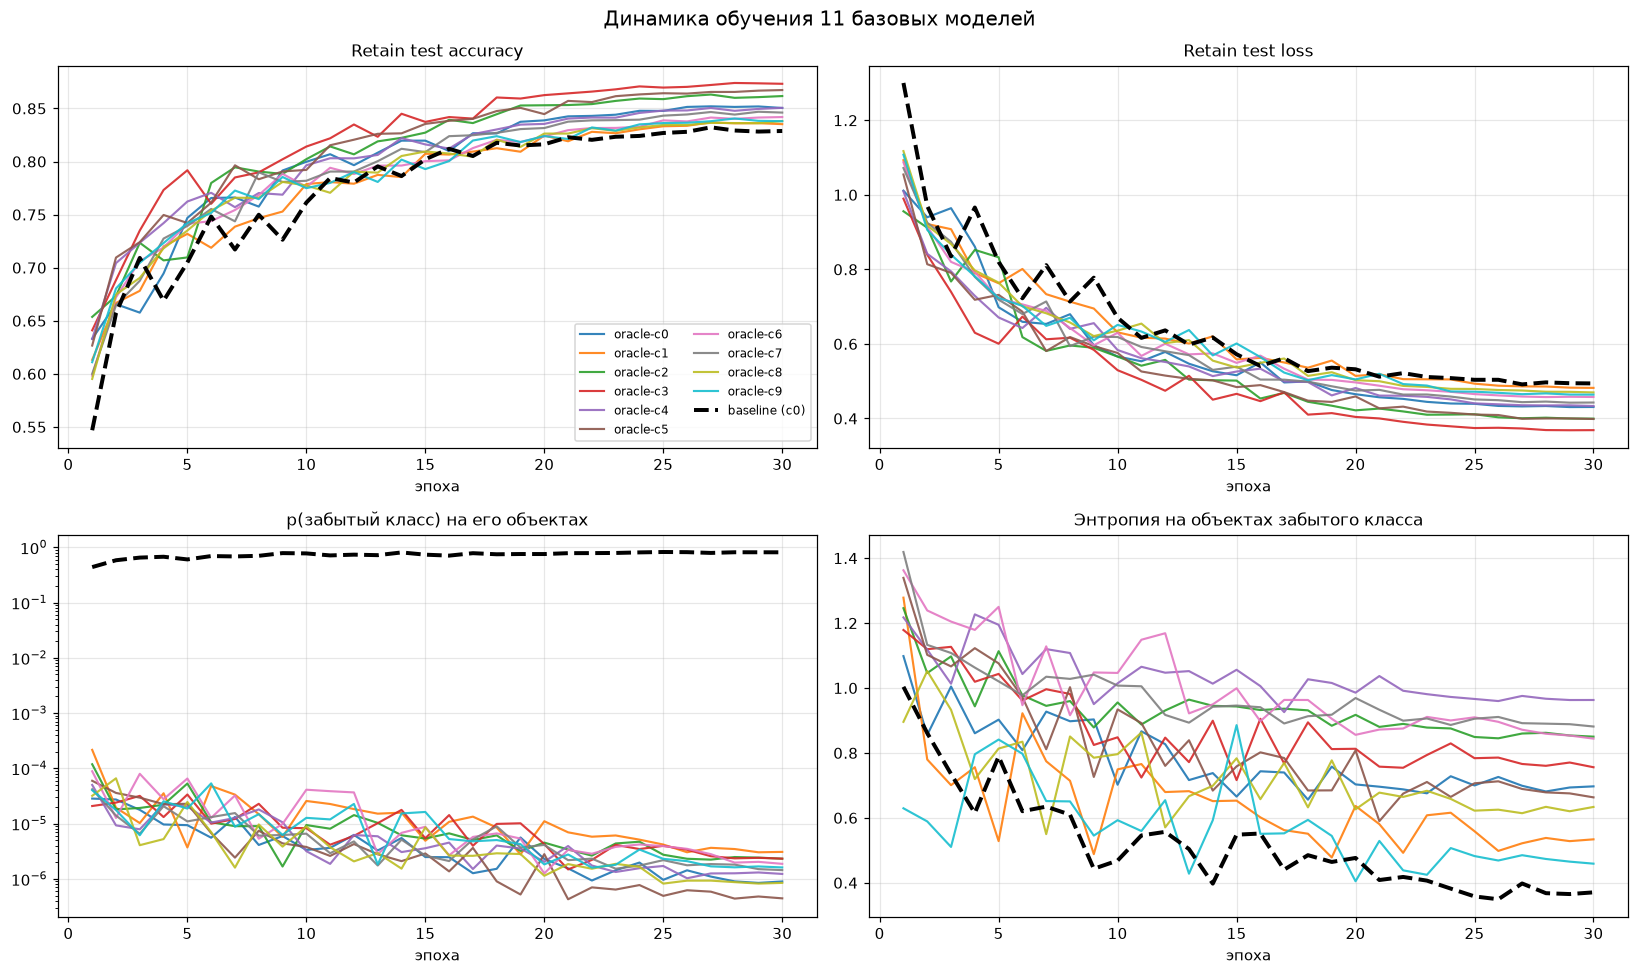

In [11]:
epoch_metrics: dict[str, list[EpochMetrics]] = {
    name: data.meta.metrics for name, data in models.items()
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
panels = [
    ("retain_test_accuracy", "Retain test accuracy", False),
    ("retain_test_loss", "Retain test loss", False),
    ("forget_test_forget_class_probability", "p(забытый класс) на его объектах", True),
    ("forget_test_entropy", "Энтропия на объектах забытого класса", False),
]
oracle_colors = {cls: plt.cm.tab10(idx % 10) for idx, cls in enumerate(CANDIDATES)}

for ax, (key, title, log_scale) in zip(axes.flat, panels):
    for cls in CANDIDATES:
        history = [getattr(epoch, key) for epoch in epoch_metrics[f"oracle-c{cls}"]]
        ax.plot(
            range(1, len(history) + 1),
            history,
            color=oracle_colors[cls],
            linewidth=1.4,
            alpha=0.9,
            label=f"oracle-c{cls}" if ax is axes.flat[0] else None,
        )
    baseline_history = [getattr(epoch, key) for epoch in epoch_metrics["baseline"]]
    ax.plot(
        range(1, len(baseline_history) + 1),
        baseline_history,
        color="black",
        linewidth=2.6,
        linestyle="--",
        label="baseline (c0)" if ax is axes.flat[0] else None,
    )
    ax.set_title(title)
    ax.set_xlabel("эпоха")
    if log_scale:
        ax.set_yscale("log")

axes.flat[0].legend(fontsize=8, ncol=2)
fig.suptitle("Динамика обучения 11 базовых моделей", fontsize=13)
fig.tight_layout()
plt.show()

## Что происходит с удаленным классом

Для каждого кандидата $C$ сравниваем baseline и `oracle-c` на объектах класса $C$:
- Слева - средняя вероятность правильного класса (baseline знает класс, oracle - нет $\Rightarrow$ логарифмическая шкала, чтобы был виден разрыв в 5-6 порядков)
- Справа - средняя максимальная уверенность: oracle не просто теряет класс, а уверенно относит его объекты к другим классам (иначе забывание было бы просто неуверенностью).

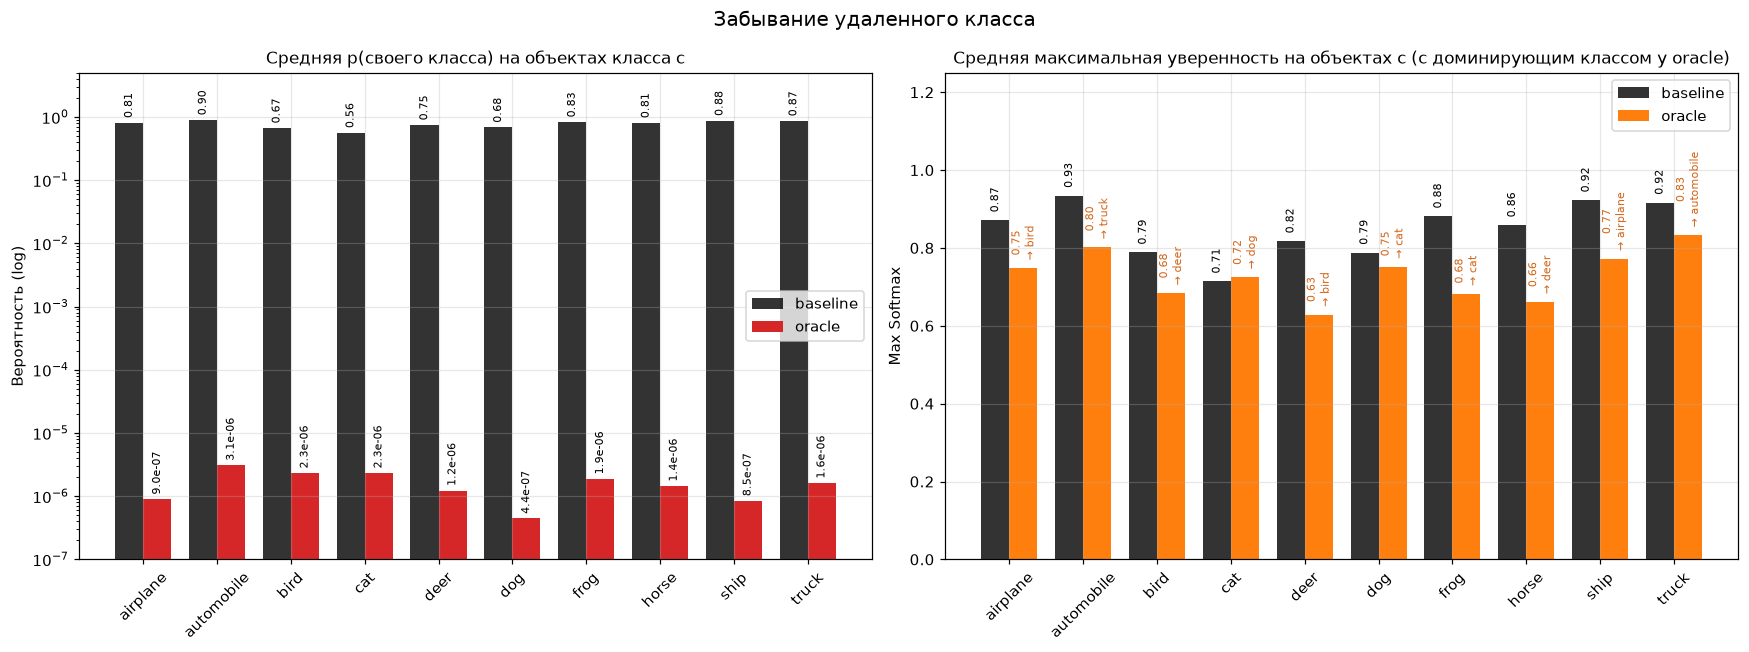

,baseline_confidence,oracle_confidence,baseline_max_confidence,oracle_max_confidence,oracle_top_class,oracle_top_class_name,oracle_top_class_share
forget_class,,,,,,,
0,0.812718,8.968339e-07,0.871570,0.748156,2,bird,0.349
1,0.897480,3.076009e-06,0.934324,0.802155,9,truck,0.709
2,0.667278,2.318091e-06,0.788663,0.683705,4,deer,0.214
3,0.563522,2.323449e-06,0.714299,0.724897,5,dog,0.516
4,0.745588,1.228244e-06,0.817459,0.628463,2,bird,0.349
5,0.683771,4.440867e-07,0.788151,0.752048,3,cat,0.634
6,0.831248,1.870484e-06,0.881451,0.682114,3,cat,0.397
7,0.808008,1.440048e-06,0.858582,0.661387,4,deer,0.435
8,0.875932,8.455664e-07,0.922680,0.772041,0,airplane,0.630


In [12]:
rows = []
for cls in CANDIDATES:
    base = evaluations["baseline"]
    oracle = evaluations[f"oracle-c{cls}"]
    confusion = oracle.class_prediction_distribution(cls)
    confusion[cls] = 0.0
    top_pred_class = int(np.argmax(confusion))

    rows.append(
        {
            "forget_class": cls,
            "baseline_confidence": base.class_confidence(cls),
            "oracle_confidence": oracle.class_confidence(cls),
            "baseline_max_confidence": base.class_max_confidence(cls),
            "oracle_max_confidence": oracle.class_max_confidence(cls),
            "oracle_top_class": top_pred_class,
            "oracle_top_class_name": CLASS_NAMES[top_pred_class],
            "oracle_top_class_share": float(confusion[top_pred_class]),
        }
    )
forgetting = pd.DataFrame(rows).set_index("forget_class")

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))
positions = np.arange(10)
width = 0.38

ax_left.bar(
    positions - width / 2,
    forgetting["baseline_confidence"],
    width,
    label="baseline",
    color="black",
    alpha=0.8,
)
ax_left.bar(
    positions + width / 2,
    forgetting["oracle_confidence"].clip(lower=1e-12),
    width,
    label="oracle",
    color="tab:red",
)
ax_left.set_yscale("log")
ax_left.set_ylim(1e-7, 5.0)
ax_left.set_xticks(positions, [CLASS_NAMES[cls] for cls in CANDIDATES], rotation=45)
ax_left.set_title("Средняя p(своего класса) на объектах класса c")
ax_left.set_ylabel("Вероятность (log)")
ax_left.legend()

for position, value in zip(positions - width / 2, forgetting["baseline_confidence"]):
    ax_left.text(
        position, value * 1.3, f"{value:.2f}", ha="center", fontsize=7, rotation=90
    )
for position, value in zip(positions + width / 2, forgetting["oracle_confidence"]):
    ax_left.text(
        position, value * 1.3, f"{value:.1e}", ha="center", fontsize=7, rotation=90
    )

ax_right.bar(
    positions - width / 2,
    forgetting["baseline_max_confidence"],
    width,
    label="baseline",
    color="black",
    alpha=0.8,
)
ax_right.bar(
    positions + width / 2,
    forgetting["oracle_max_confidence"],
    width,
    label="oracle",
    color="tab:orange",
)
ax_right.set_xticks(positions, [CLASS_NAMES[cls] for cls in CANDIDATES], rotation=45)
ax_right.set_title(
    "Средняя максимальная уверенность на объектах c (с доминирующим классом у oracle)"
)
ax_right.set_ylabel("Max Softmax")
ax_right.set_ylim(0, 1.25)
ax_right.legend(loc="upper right")

for position, value in zip(
    positions - width / 2, forgetting["baseline_max_confidence"]
):
    ax_right.text(
        position,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )

for position, value, target_name in zip(
    positions + width / 2,
    forgetting["oracle_max_confidence"],
    forgetting["oracle_top_class_name"],
):
    ax_right.text(
        position,
        value + 0.02,
        f"{value:.2f}\n→ {target_name}",
        ha="center",
        va="bottom",
        fontsize=7.5,
        rotation=90,
        color="chocolate",
    )

fig.suptitle("Забывание удаленного класса", fontsize=13)
fig.tight_layout()
plt.show()

forgetting

## Куда уходит удаленный класс

Куда oracle относит объекты удаленного класса. Это целевое поведение для unlearning: чем концентрированнее распределение, тем детерминированнее и проще измерить результат забывания.

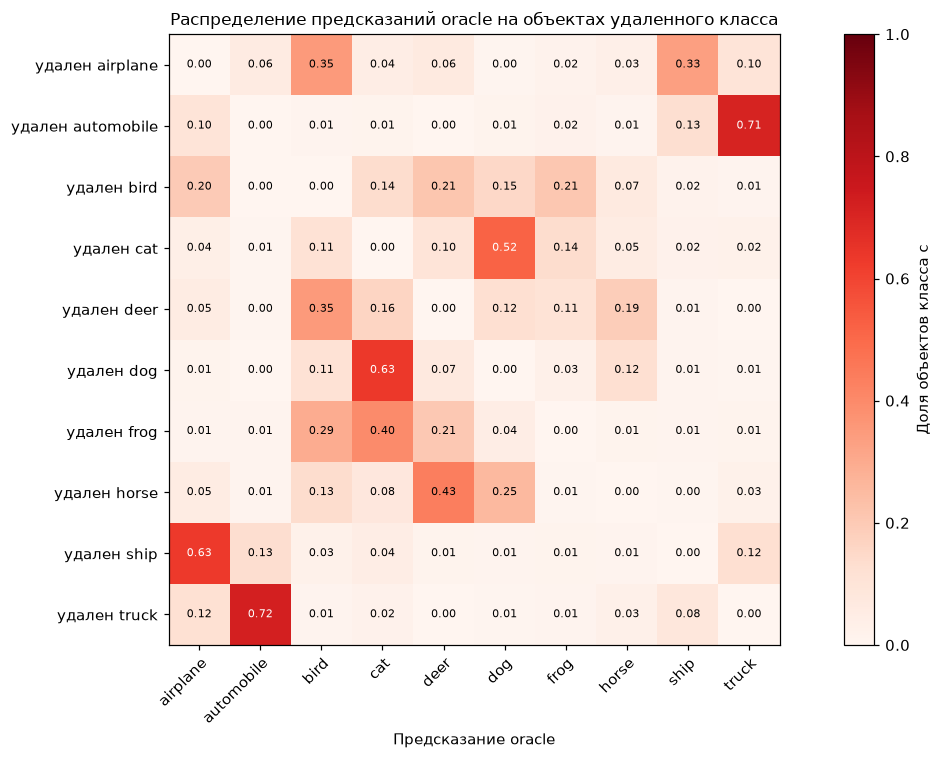

,oracle_collapse_class,oracle_collapse_share,oracle_class_entropy,oracle_class_confidence
forget_class,,,,
0,2,0.349,0.697016,8.968339e-07
1,9,0.709,0.533800,3.076009e-06
2,4,0.214,0.850126,2.318091e-06
3,5,0.516,0.755880,2.323449e-06
4,2,0.349,0.963061,1.228244e-06
5,3,0.634,0.663117,4.440867e-07
6,3,0.397,0.843999,1.870484e-06
7,4,0.435,0.881340,1.440048e-06
8,0,0.630,0.633576,8.455664e-07


In [15]:
confusion = pd.DataFrame(
    {
        CLASS_NAMES[cls]: {
            CLASS_NAMES[predicted]: (
                0.0
                if predicted == cls
                else evaluations[f"oracle-c{cls}"].class_prediction_distribution(cls)[
                    predicted
                ]
            )
            for predicted in range(10)
        }
        for cls in CANDIDATES
    }
).T

fig, ax = plt.subplots(figsize=(12, 7))
image = ax.imshow(confusion.to_numpy(), cmap="Reds", vmin=0.0, vmax=1.0)
ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(10), [f"удален {name}" for name in confusion.index])
ax.set_xlabel("Предсказание oracle")
ax.set_title("Распределение предсказаний oracle на объектах удаленного класса")
ax.grid(False)

for row in range(10):
    for column in range(10):
        value = confusion.iat[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black" if value < 0.5 else "white",
        )

fig.colorbar(image, ax=ax, label="Доля объектов класса c")
fig.tight_layout()
plt.show()

criteria[
    [
        "oracle_collapse_class",
        "oracle_collapse_share",
        "oracle_class_entropy",
        "oracle_class_confidence",
    ]
]

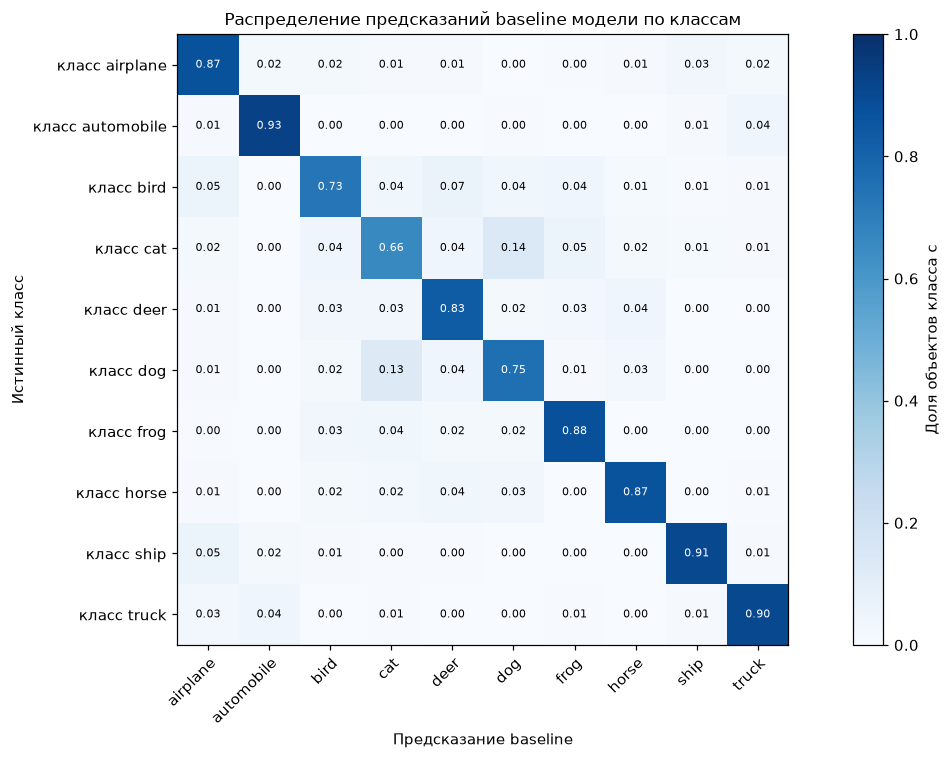

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,0.871,0.016,0.022,0.009,0.011,0.002,0.004,0.009,0.034,0.022
automobile,0.009,0.930,0.001,0.002,0.001,0.004,0.002,0.000,0.010,0.041
bird,0.052,0.000,0.734,0.036,0.066,0.038,0.045,0.013,0.005,0.011
cat,0.023,0.003,0.044,0.658,0.043,0.139,0.052,0.018,0.012,0.008
deer,0.008,0.002,0.034,0.032,0.829,0.023,0.027,0.043,0.001,0.001
dog,0.011,0.001,0.023,0.128,0.040,0.754,0.009,0.030,0.001,0.003
frog,0.004,0.002,0.033,0.039,0.016,0.021,0.878,0.003,0.002,0.002
horse,0.011,0.001,0.018,0.024,0.039,0.033,0.002,0.867,0.000,0.005
ship,0.051,0.016,0.008,0.004,0.004,0.001,0.001,0.002,0.905,0.008
truck,0.025,0.044,0.002,0.007,0.000,0.002,0.005,0.002,0.009,0.904


In [16]:
base = evaluations["baseline"]

confusion_baseline = pd.DataFrame(
    {
        CLASS_NAMES[cls]: {
            CLASS_NAMES[predicted]: base.class_prediction_distribution(cls)[predicted]
            for predicted in range(10)
        }
        for cls in CANDIDATES
    }
).T

fig, ax = plt.subplots(figsize=(12, 7))
image = ax.imshow(confusion_baseline.to_numpy(), cmap="Blues", vmin=0.0, vmax=1.0)
ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(10), [f"класс {name}" for name in confusion_baseline.index])
ax.set_xlabel("Предсказание baseline")
ax.set_ylabel("Истинный класс")
ax.set_title("Распределение предсказаний baseline модели по классам")
ax.grid(False)

for row in range(10):
    for column in range(10):
        value = confusion_baseline.iat[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if value > 0.5 else "black",
        )

fig.colorbar(image, ax=ax, label="Доля объектов класса c")
fig.tight_layout()
plt.show()

confusion_baseline

## Уверенность и энтропия на объектах удаленного класса

Распределения по отдельным объектам: сравнение baseline и соответствующего oracle:
- Слева - энтропия предсказания: низкая энтропия = модель уверена (неважно, права она или нет)
- Справа — максимальная вероятность

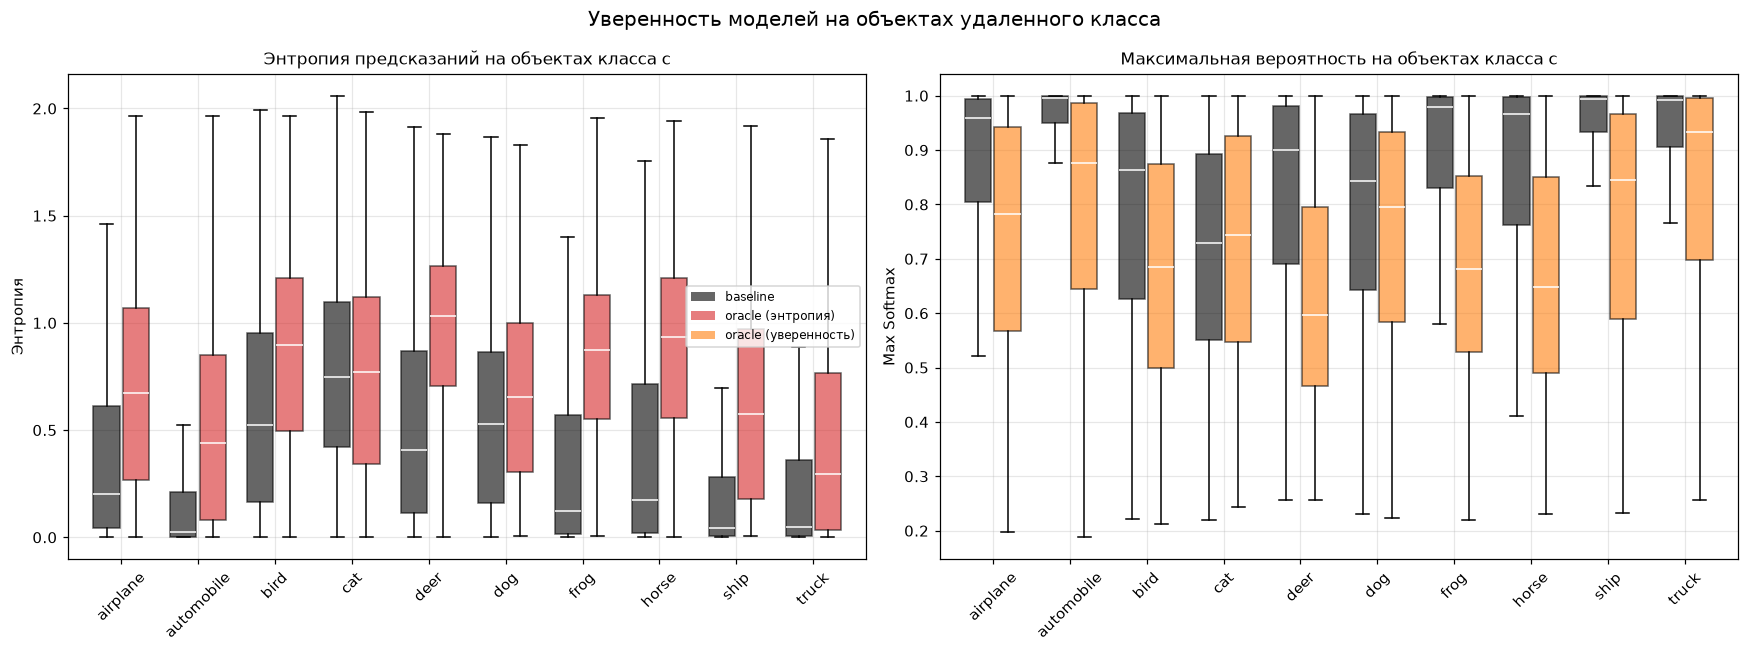

In [ ]:
fig, (ax_entropy, ax_confidence) = plt.subplots(1, 2, figsize=(16, 6))
positions = np.arange(1, 11)

base = evaluations["baseline"]
boxplot_style: dict[str, Any] = {"showfliers": False}
ax_entropy.boxplot(
    [base.class_sample_entropy(cls) for cls in CANDIDATES],
    positions=positions - 0.19,
    widths=0.34,
    patch_artist=True,
    boxprops={"facecolor": "black", "alpha": 0.6},
    medianprops={"color": "white"},
    **boxplot_style,
)
ax_confidence.boxplot(
    [base.class_sample_max_confidence(cls) for cls in CANDIDATES],
    positions=positions - 0.19,
    widths=0.34,
    patch_artist=True,
    boxprops={"facecolor": "black", "alpha": 0.6},
    medianprops={"color": "white"},
    **boxplot_style,
)

ax_entropy.boxplot(
    [evaluations[f"oracle-c{cls}"].class_sample_entropy(cls) for cls in CANDIDATES],
    positions=positions + 0.19,
    widths=0.34,
    patch_artist=True,
    boxprops={"facecolor": "tab:red", "alpha": 0.6},
    medianprops={"color": "white"},
    **boxplot_style,
)
ax_confidence.boxplot(
    [
        evaluations[f"oracle-c{cls}"].class_sample_max_confidence(cls)
        for cls in CANDIDATES
    ],
    positions=positions + 0.19,
    widths=0.34,
    patch_artist=True,
    boxprops={"facecolor": "tab:orange", "alpha": 0.6},
    medianprops={"color": "white"},
    **boxplot_style,
)

for ax, title, label in (
    (ax_entropy, "Энтропия предсказаний на объектах класса c", "Энтропия"),
    (ax_confidence, "Максимальная вероятность на объектах класса c", "Max Softmax"),
):
    ax.set_xticks(positions, [CLASS_NAMES[cls] for cls in CANDIDATES], rotation=45)
    ax.set_title(title)
    ax.set_ylabel(label)

handles = [
    matplotlib_patches.Rectangle((0, 0), 1, 1, facecolor="black", alpha=0.6),
    matplotlib_patches.Rectangle((0, 0), 1, 1, facecolor="tab:red", alpha=0.6),
    matplotlib_patches.Rectangle((0, 0), 1, 1, facecolor="tab:orange", alpha=0.6),
]
ax_entropy.legend(
    handles, ["baseline", "oracle (энтропия)", "oracle (уверенность)"], fontsize=8
)
fig.suptitle("Уверенность моделей на объектах удаленного класса", fontsize=13)
fig.tight_layout()
plt.show()

## Критерий выбора целевого класса

Правильно ответа какой класс удалять - нет, но как мне кажется выбрать нужно ту модель, у которой:
1) Класс, который baseline модель будет забывать, должен быть хорошо выучен (если это не так, то забывать просто нечего)
2) `retention_mean_delta` должен быть минимальным. Все oracle модели на оставшихся классах в среднем лучше чем baseline модель. В процессе забывания в хорошей ситуации эта метрика останется такой же, но если она вырастет это будет означать, что baseline модель стала еще хуже
3) Низкий `collapse` и высокая энтропия. Oracle должна быть не уверена в забытом классе. Например, если выбрать класс `truck`, в котором у модели $0.72$ accuracy для класса `automobile`, то по итогам unlearning baseline модель должна начать уверенно вместо `truck` предсказывать `automobile`
4) Высокий `retention_worst_delta`. Если этот показатель будет низким и после забывания модель продолжит хорошо классифицировать этот класс, тогда unlearning покажет точность выше oracle, хотя задача unlearning приблизиться к oracle
5) Низкий `retention_best_delta`. Если показатель будет высоким, то после unlearning он станет еще выше и разница между oracle и unlearning увеличится